<>:102: SyntaxWarning: invalid escape sequence '\O'
<>:102: SyntaxWarning: invalid escape sequence '\O'
C:\Users\nilak\AppData\Local\Temp\ipykernel_26800\1548339214.py:102: SyntaxWarning: invalid escape sequence '\O'
  axs[0, 1].set_ylabel('Ohms ($\Omega$)')


Enter nominal capacity 3.7
Enter constant charge current 2
enter initial soc 0.95


     cycle  time_s  voltage_v  current_a
0        1       0   4.305543    3.69556
1        1     360   3.974457   -3.69556
2        1     720   3.779629   -3.69556
3        1    1080   3.519858   -3.69556
4        1    1440   3.195144   -3.69556
..     ...     ...        ...        ...
204     98   73440  -7.008114   -3.26488
205     99   73800   8.473684    3.26044
206     99   74160  -7.082324   -3.26044
207    100   74520   8.568772    3.25600
208    100   74880  -7.156634   -3.25600

[209 rows x 4 columns]


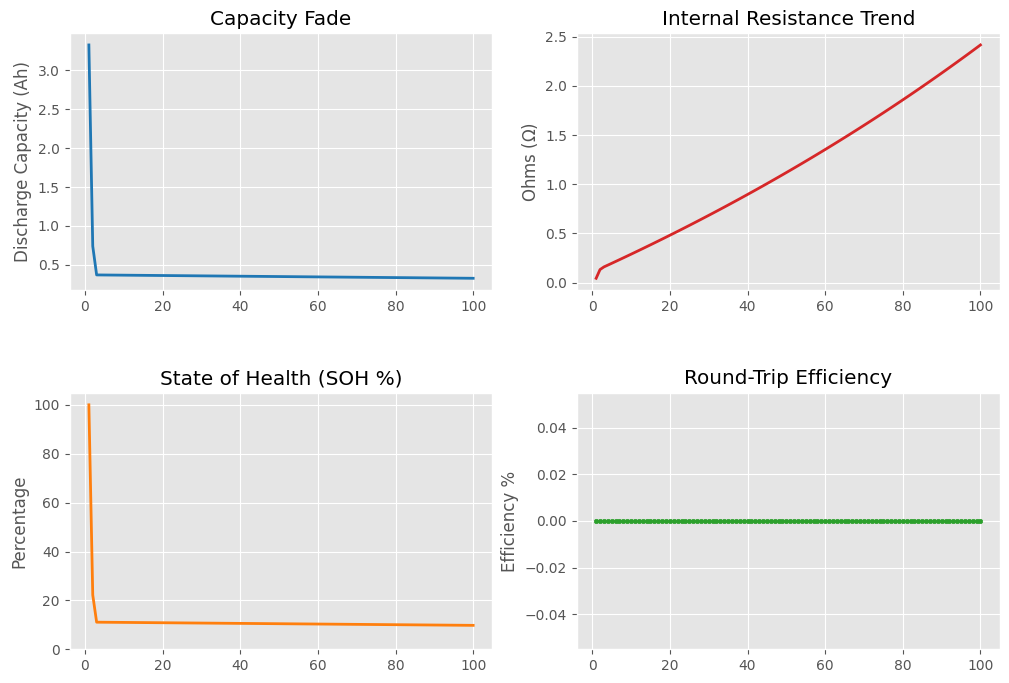

Final Battery Status
 Cycle  Capacity_Ah  Efficiency  Resistance      SOH
   100       0.3256           0    2.414835 9.789525


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def generate_battery_cycles(num_cycles=100):
    """Generates synthetic V, I, T data for analysis."""
    all_data = []
    current_time =0
    nominal_cap = float(input("Enter nominal capacity"))  # 3.7 Ah battery
    I_charge    = float(input("Enter constant charge current")) # constant charge current (CC phase)
    I_discharge = -I_charge #constant discharge current
    dt_s        = 360.0  
    soc= float(input("enter initial soc"))
    for cycle in range(1, num_cycles + 1):
        # Degrade capacity and increase resistance slightly each cycle
        degradation_factor = (1 - (cycle * 0.0012)) 
        actual_cap = nominal_cap * degradation_factor
        resistance = 0.05 * (1 + (cycle * 0.006))
        n_charge=max(1,int(round(actual_cap*3600 / (I_discharge * dt_s))))
        
        for _ in range(n_charge):
            soc = soc + (I_charge * dt_s) / (actual_cap * 3600)
            #soc=min(soc,1)
            voltage = 3.0 + 1.2 * soc +(I_charge*resistance)  # simple linear OCV curve
            all_data.append([cycle, current_time,voltage, actual_cap])
            current_time += 360 # 6-minute steps
            dt_s+=360
        n_discharge = max(1, int(round(actual_cap * 3600 / (abs(I_discharge) *dt_s))))
        for _ in range(n_discharge):
            # Voltage drops due to IR loss and depth of discharge
            soc = soc - (abs(I_discharge) * dt_s) / (actual_cap * 3600)
            #soc = max(soc, 0.0)
            voltage = 3.0 + 1.2 * soc - (abs(I_discharge) * resistance)
            all_data.append([cycle, current_time, voltage,-actual_cap])
            current_time += 360
            dt_s+=360
    return pd.DataFrame(all_data, columns=['cycle', 'time_s', 'voltage_v', 'current_a'])

def analyze_battery(df):
    results = []
    first_cycle_capacity = None
    
    for cycle_num, group in df.groupby('cycle'):
        # Calculate time steps (dt)
        group = group.copy()
        group['dt'] = group['time_s'].diff().fillna(0)

        # Current * time / 3600 (to get hours)
        group['ah_step'] = (group['current_a'].abs() * group['dt']) / 3600
        q_charge = group[group['current_a'] > 0]['ah_step'].sum()
        q_discharge = group[group['current_a'] < 0]['ah_step'].sum()
        
        # Power = V * I -> Energy = V * I * dt
        group['energy_wh'] = (group['voltage_v'] * group['current_a'].abs() * group['dt']) / 3600.0
        e_charge = group[group['current_a'] > 0]['energy_wh'].sum()
        e_discharge = group[group['current_a'] < 0]['energy_wh'].sum()
        efficiency = (e_discharge / e_charge * 100) if e_charge > 0 else 0
        
        # Internal Resistance Logic (Ohm's Law)
        v_diff = group['voltage_v'].diff().abs()
        i_diff = group['current_a'].diff().abs()
       
        mask = i_diff > 0.1 
        res_values = v_diff[mask] / i_diff[mask]
        avg_resistance = res_values.mean() if not res_values.empty else 0
        
        # 4. State of Health (SOH) Logic
        if first_cycle_capacity is None and q_discharge > 0:
            first_cycle_capacity = q_discharge
            
        # Safe division to prevent RuntimeWarning
        soh = (q_discharge / first_cycle_capacity * 100) if first_cycle_capacity else 100.0
        
        results.append({
            'Cycle': cycle_num,
            'Capacity_Ah': q_discharge,
            'Efficiency': efficiency,
            'Resistance': avg_resistance,
            'SOH': soh
        })
        
    return pd.DataFrame(results)
    
# Data
raw_data = generate_battery_cycles(100)
print(raw_data)
# Run Analysis
report = analyze_battery(raw_data)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
plt.subplots_adjust(hspace=0.4)

# Capacity Fade
axs[0, 0].plot(report['Cycle'], report['Capacity_Ah'], color='tab:blue', linewidth=2)
axs[0, 0].set_title('Capacity Fade')
axs[0, 0].set_ylabel('Discharge Capacity (Ah)')

# Resistance Growth
axs[0, 1].plot(report['Cycle'], report['Resistance'], color='tab:red', linewidth=2)
axs[0, 1].set_title('Internal Resistance Trend')
axs[0, 1].set_ylabel('Ohms ($\Omega$)')

# SOH
axs[1, 0].plot(report['Cycle'], report['SOH'], color='tab:orange', linewidth=2)
axs[1, 0].set_title('State of Health (SOH %)')
axs[1, 0].set_ylabel('Percentage')
axs[1, 0].set_ylim(0, 105)

# Efficiency
axs[1, 1].scatter(report['Cycle'], report['Efficiency'], color='tab:green', s=10)
axs[1, 1].set_title('Round-Trip Efficiency')
axs[1, 1].set_ylabel('Efficiency %')

plt.show()

print("Final Battery Status")
print(report.tail(1).to_string(index=False))